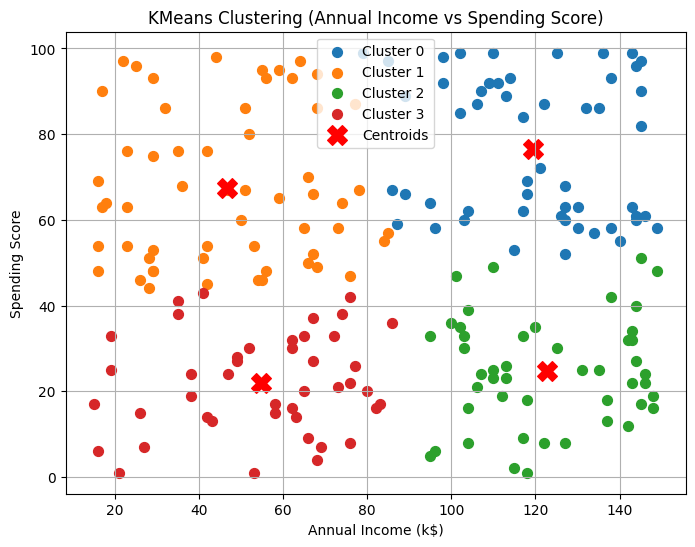

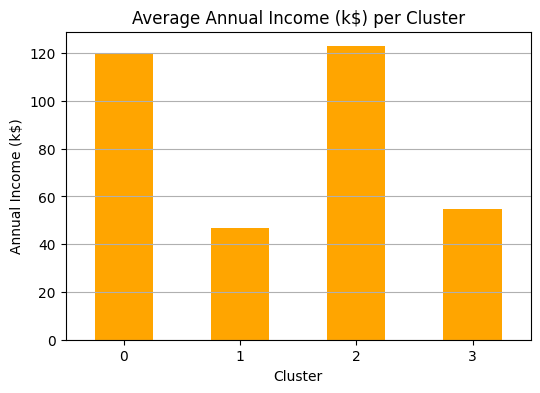

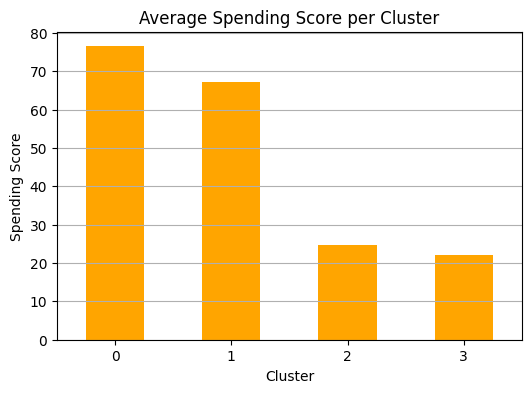

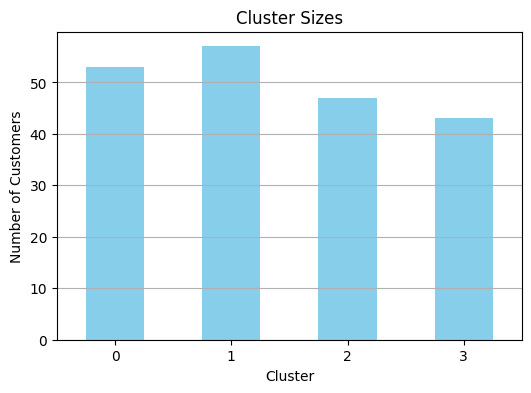

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Step 1: Create synthetic customer data
np.random.seed(42)
n_samples = 200
income = np.random.randint(15, 150, size=n_samples)
spending_score = np.random.randint(1, 100, size=n_samples)
df = pd.DataFrame({
   'Annual Income (k$)': income,
   'Spending Score': spending_score
})
# Step 2: Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
# Step 3: KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=100, n_init=1)
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Step 4: Scatter plot (2D, no PCA)
plt.figure(figsize=(8, 6))
for cluster in sorted(df['Cluster'].unique()):
   cluster_data = df[df['Cluster'] == cluster]
   plt.scatter(cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score'],
               label=f'Cluster {cluster}', s=50)
# Plot cluster centers (scaled back to original range)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
           c='red', marker='X', s=200, label='Centroids')
plt.title("KMeans Clustering (Annual Income vs Spending Score)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)
plt.show()
# Step 5: Cluster summary bar plots
cluster_means = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score']].mean()
for feature in cluster_means.columns:
   plt.figure(figsize=(6, 4))
   cluster_means[feature].plot(kind='bar', color='orange')
   plt.title(f"Average {feature} per Cluster")
   plt.xlabel("Cluster")
   plt.ylabel(f"{feature}")
   plt.xticks(rotation=0)
   plt.grid(axis='y')
   plt.show()
# Optional: Cluster sizes
plt.figure(figsize=(6, 4))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()